# Logging into huggingface

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

# Loading dataset

In [ ]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
splits = {'train': 'en/train-00000-of-00001.parquet', 
          'validation': 'en/validation-00000-of-00001.parquet'}

training_df = pd.read_parquet("hf://datasets/mteb/AmazonReviewsClassification/" + splits["train"])

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/mteb/AmazonReviewsClassification/resolve/main/en/train-00000-of-00001.parquet
Retrying in 1s [Retry 1/5].


# Exploring dataset

In [2]:
training_df.head()

,text,label
0,I'll spend twice the amount of time boxing up ...,0
1,Not use able\n\nthe cabinet dot were all detac...,0
2,The product is junk.\n\nI received my first or...,0
3,Fucking waste of money\n\nThis product is a pi...,0
4,bubble\n\nwent through 3 in one day doesn't fi...,0


In [3]:
training_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    200000 non-null  object
 1   label   200000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [4]:
training_df["label"].value_counts()

label
0    40000
1    40000
2    40000
3    40000
4    40000
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

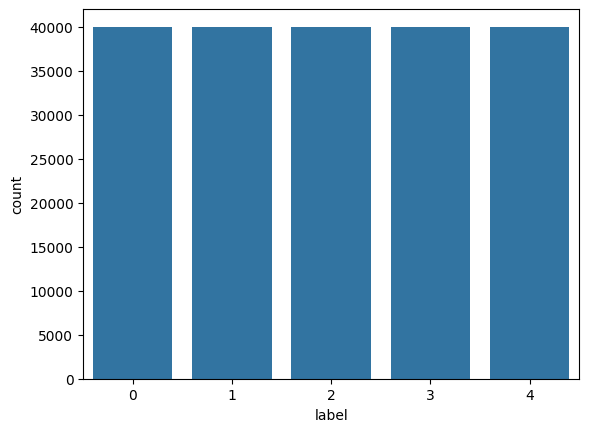

In [5]:
import seaborn as sns

sns.countplot(training_df, x="label")

In [6]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

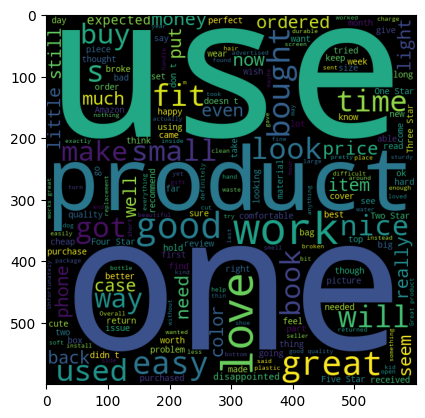

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

corpus = " ".join(training_df["text"])

wordcloud = WordCloud(height=600, width=600)
wordcloud.generate(corpus)

plt.imshow(wordcloud)

# Preprocessing

### Text cleaning

In [5]:
from nltk.corpus import stopwords

stop_words = stopwords.words("english")

In [6]:
from nltk.tokenize import word_tokenize
import re

def clean_text(text: str):
    #removing newline and tab characters
    text = text = text.replace('\n', ' ').replace('\t', ' ')
    
    #lower casing text
    text = text.lower()
    
    #removing any character that is not alphanumeric
    text = text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    #tokeinzing the text
    words = word_tokenize(text)
    
    #cleaning the text
    cleaned_words = [word for word in words if word not in stop_words]
    
    #returning cleaned text
    return " ".join(cleaned_words)

In [10]:
training_df["cleaned_text"] = training_df["text"].apply(clean_text)

training_df[["text", "cleaned_text"]].head()

,text,cleaned_text
0,I'll spend twice the amount of time boxing up ...,ill spend twice amount time boxing whole usele...
1,Not use able\n\nthe cabinet dot were all detac...,use able cabinet dot detached backing got
2,The product is junk.\n\nI received my first or...,product junk received first order product brok...
3,Fucking waste of money\n\nThis product is a pi...,fucking waste money product piece shit buy doe...
4,bubble\n\nwent through 3 in one day doesn't fi...,bubble went 3 one day doesnt fit correct could...


### Label Collapsing

In [11]:
sentiment_mapping = {
    0: "Negative",
    1: "Negative", 
    2: "Neutral",
    3: "Positive",
    4: "Positive"
}

training_df["sentiment"] = training_df["label"].map(sentiment_mapping)

training_df[["label", "sentiment"]].value_counts()

label  sentiment
0      Negative     40000
1      Negative     40000
2      Neutral      40000
3      Positive     40000
4      Positive     40000
Name: count, dtype: int64

### Label encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

training_df["encoded_sentiment"] = encoder.fit_transform(training_df["sentiment"])

training_df[["sentiment", "encoded_sentiment"]].value_counts()

sentiment  encoded_sentiment
Negative   0                    80000
Positive   2                    80000
Neutral    1                    40000
Name: count, dtype: int64

### Vectorizing cleaned text

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizor = TfidfVectorizer()

x = vectorizor.fit_transform(training_df["cleaned_text"])

# Training logestic regression model for sentiment analysis

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X=x, y=training_df["encoded_sentiment"].values)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### saving trained vectorizor, encoder and model

In [17]:
import pickle

#saving model
with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)
    
#saving vectorizor
with open("tfidf_vectorizor.pkl", "wb") as f:
    pickle.dump(vectorizor, f)
    
#saving encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

### validating the model using validation fold

In [1]:
import pickle

#loading model
with open("logistic_regression_model.pkl", "rb") as f:
   model =  pickle.load(f)
    
#loading vectorizor
with open("tfidf_vectorizor.pkl", "rb") as f:
    vectorizor = pickle.load(f)
    
#loading encoder
with open("label_encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

In [3]:
import pandas as pd

splits = {'train': 'en/train-00000-of-00001.parquet', 
          'validation': 'en/validation-00000-of-00001.parquet'}

validation_df = pd.read_parquet("hf://datasets/mteb/AmazonReviewsClassification/" + splits["validation"])

In [7]:
sentiment_mapping = {
    0: "Negative",
    1: "Negative", 
    2: "Neutral",
    3: "Positive",
    4: "Positive"
}

validation_df["cleaned_text"] = validation_df["text"].apply(clean_text)

validation_df["sentiment"] = validation_df["label"].map(sentiment_mapping)

validation_df["encoded_sentiment"] = encoder.transform(validation_df["sentiment"])

validation_df[["sentiment", "encoded_sentiment"]].value_counts()

sentiment  encoded_sentiment
Negative   0                    2000
Positive   2                    2000
Neutral    1                    1000
Name: count, dtype: int64

In [8]:
x_val = vectorizor.transform(validation_df["cleaned_text"])

In [9]:
y_val = model.predict(x_val)

In [10]:
from sklearn.metrics import classification_report

print(classification_report(validation_df["encoded_sentiment"].values, y_val))

              precision    recall  f1-score   support

           0       0.79      0.73      0.76      2000
           1       0.43      0.53      0.47      1000
           2       0.84      0.79      0.81      2000

    accuracy                           0.72      5000
   macro avg       0.68      0.69      0.68      5000
weighted avg       0.74      0.72      0.72      5000



<Axes: >

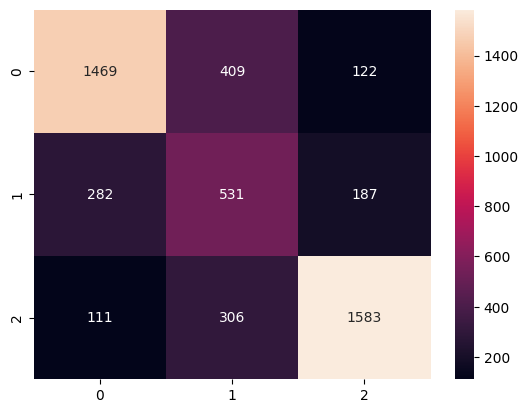

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(validation_df["encoded_sentiment"].values, y_val, labels=[0, 1, 2]), fmt='d', annot=True)